h = 0.010   avg error = 0.368561  local error @ x≈15: 0.040935  
h = 0.050   avg error = 1.258792  local error @ x≈15: 0.152506  
h = 0.150   avg error = 1.950547  local error @ x≈15: 0.251454  
h = 0.200   avg error = 2.059003  local error @ x≈15: 0.264472  
h = 0.250   avg error = 2.130091  local error @ x≈15: 0.269713  
h = 0.300   avg error = 2.172528  local error @ x≈15: 0.271622  
h = 0.350   avg error = 2.200846  local error @ x≈15: 0.294172  
h = 0.400   avg error = 2.214620  local error @ x≈15: 0.206679  
h = 0.450   avg error = 2.232445  local error @ x≈15: 0.220242  
h = 0.500   avg error = 2.239393  local error @ x≈15: 0.272375  
h = 0.550   avg error = 2.217616  local error @ x≈15: 0.220243  
h = 0.600   avg error = 2.219700  local error @ x≈15: 0.272375  
h = 0.650   avg error = 2.206864  local error @ x≈15: 0.252852  
h = 0.700   avg error = 2.213891  local error @ x≈15: 0.184239  
h = 0.750   avg error = 2.186116  local error @ x≈15: 0.270801  
h = 0.800   avg error = 2

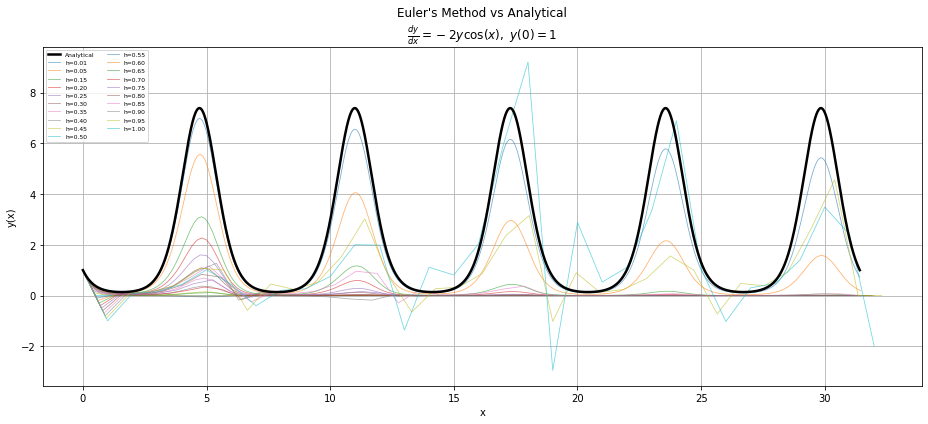

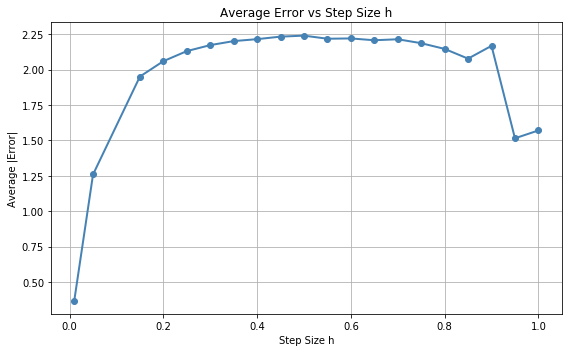

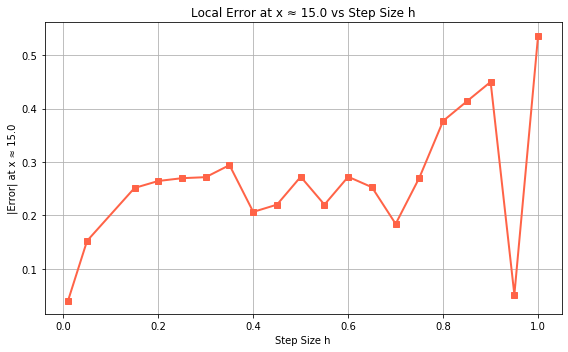

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y * np.cos(x)

def analytical(x):
    return np.exp(-2 * np.sin(x))

x_start, x_end = 0, 10 * np.pi
step_sizes = [0.01, 0.05] + list(np.round(np.arange(0.15, 1.01, 0.05), 10))

x_target = 15.0  # x ≈ 15

avg_errors  = []
local_errors = []
hs_used     = []

plt.figure(1, figsize=(13, 6))
x_exact = np.linspace(x_start, x_end, 10000)
y_exact = analytical(x_exact)
plt.plot(x_exact, y_exact, 'k-', linewidth=2.5, label='Analytical', zorder=5)

for h in step_sizes:
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = 1.0

    blown = False
    for i in range(1, len(x_values)):
        y_new = y_values[i-1] + h * f(x_values[i-1], y_values[i-1])
        if not np.isfinite(y_new) or abs(y_new) > 1e10:
            blown = True
            x_values = x_values[:i]
            y_values = y_values[:i]
            break
        y_values[i] = y_new

    y_analytical_at_x = analytical(x_values)
    errors = np.abs(y_values - y_analytical_at_x)
    avg_err = np.mean(errors)

    # local error at x ≈ 15
    idx = np.argmin(np.abs(x_values - x_target))
    x_close = x_values[idx]
    y_euler_15 = y_values[idx]
    y_exact_15 = analytical(x_close)
    local_err = abs(y_euler_15 - y_exact_15)

    status = "BLEW UP" if blown else f"avg err={avg_err:.5f}"
    print(f"h = {h:<6.3f}  avg error = {avg_err:.6f}  "
          f"local error @ x≈15: {local_err:.6f}  {'' if not blown else '-> BLEW UP'}")

    avg_errors.append(avg_err)
    local_errors.append(local_err)
    hs_used.append(h)

    plt.plot(x_values, y_values, alpha=0.6, linewidth=0.8, label=f'h={h:.2f}')

plt.xlabel('x')
plt.ylabel('y(x)')
plt.title("Euler's Method vs Analytical\n"
          r"$\frac{dy}{dx} = -2y\cos(x),\ y(0)=1$")
plt.legend(fontsize=6, ncol=2)
plt.grid(True)
plt.tight_layout()

# Plot 2: average error vs h
plt.figure(2, figsize=(8, 5))
plt.plot(hs_used, avg_errors, 'o-', color='steelblue', linewidth=2, markersize=6)
plt.xlabel('Step Size h')
plt.ylabel('Average |Error|')
plt.title('Average Error vs Step Size h')
plt.grid(True)
plt.tight_layout()

# Plot 3: local error at x ≈ 15 vs h
plt.figure(3, figsize=(8, 5))
plt.plot(hs_used, local_errors, 's-', color='tomato', linewidth=2, markersize=6)
plt.xlabel('Step Size h')
plt.ylabel(f'|Error| at x ≈ {x_target}')
plt.title(f'Local Error at x ≈ {x_target} vs Step Size h')
plt.grid(True)
plt.tight_layout()

plt.show()

#Lower step size yields better solutions, no solutions are extremely unstable because this is not a "stiff" ODE.